<a href="https://colab.research.google.com/github/Valedulu/greends-avcad-ex3/blob/main/Exercise3_Hannah_and_Luis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3 — Univariate Analysis of Annual Mean Temperature

**Dataset:** EFIplus_medit.zip  
**Variable of interest:**  — Annual Mean Temperature (°C)  
**Focus:** Top 4 catchments with the highest number of fish sampling sites

In [4]:
!pip install ptitprince

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt


## 1. Load and Clean the Dataset

In [6]:
from google.colab import files
uploaded = files.upload()

Saving EFIplus_medit.zip to EFIplus_medit.zip


In [7]:
df = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')

# Remove unnecessary columns and rename
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))

# Drop rows with missing values
df2 = df.dropna()
print(f"Rows after cleaning: {len(df2)}")


Rows after cleaning: 2822


## 2. Identify the Top 4 Catchments

In [8]:
# Top 4 catchments by number of fish sampling sites
top4 = df2['Catchment_name'].value_counts().head(4).index.tolist()
print("Top 4 catchments:", top4)
print()
print(df2['Catchment_name'].value_counts().head(4))

# Filter dataset to top 4 catchments only
df_top4 = df2[df2['Catchment_name'].isin(top4)].copy()

# Shared settings
palette = dict(zip(top4, sns.color_palette("colorblind", 4)))
TITLE_FS, LABEL_FS, TICK_FS = 13, 11, 9
VAR_LABEL = "Annual Mean Temperature (°C)"

def clean_ax(ax):
    """Remove chartjunk following Tufte principles."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=TICK_FS)


Top 4 catchments: ['Galiza-Norte', 'Minho', 'Cantabrica', 'Douro']

Catchment_name
Galiza-Norte    702
Minho           699
Cantabrica      345
Douro           272
Name: count, dtype: int64


## 3. Strip Plots

Strip plots show each individual data point, making them ideal for small-to-medium datasets. They reveal the full distribution, clusters, and outliers directly. The mean is shown as a dashed line for reference.

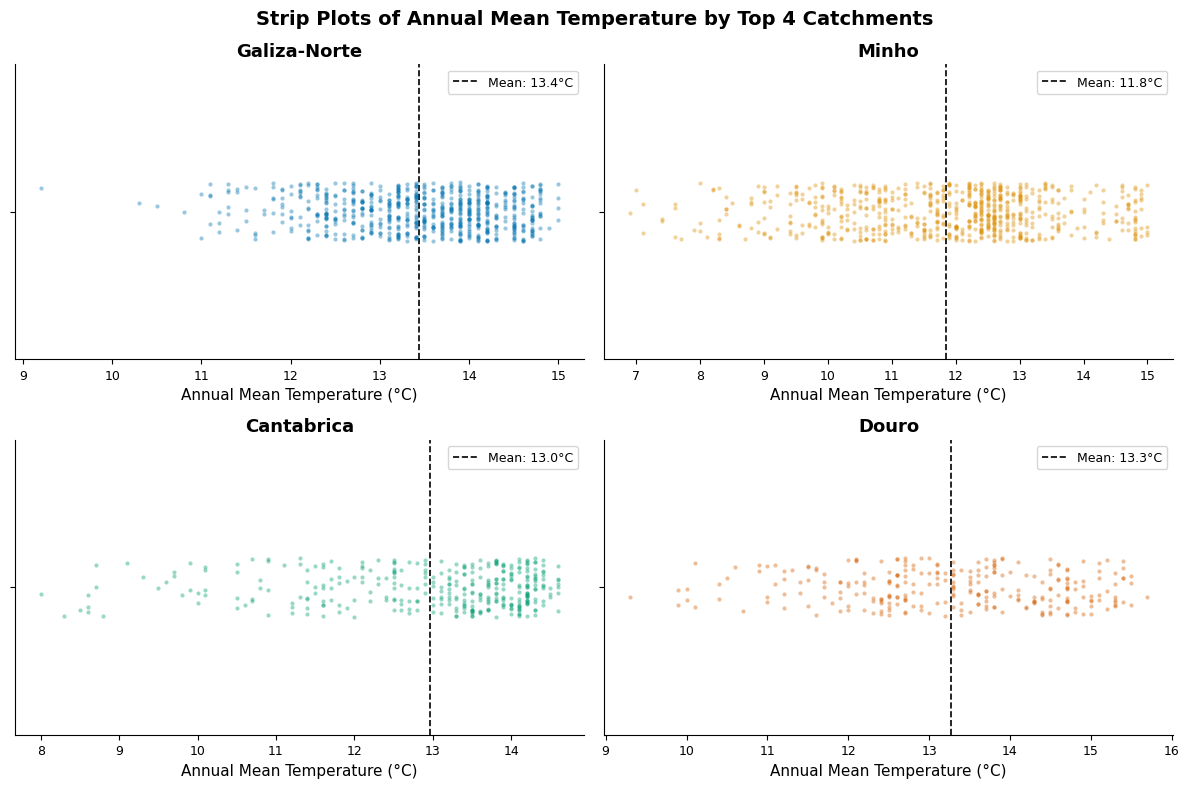

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
fig.suptitle('Strip Plots of Annual Mean Temperature by Top 4 Catchments', fontsize=TITLE_FS+1, fontweight='bold'),

for ax, catchment in zip(axes.flatten(), top4):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.stripplot(x=data, color=palette[catchment], alpha=0.4, size=3, ax=ax)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {data.mean():.1f}°C')
    ax.set_title(catchment, fontsize=TITLE_FS, fontweight='bold')
    ax.set_xlabel(VAR_LABEL, fontsize=LABEL_FS)
    ax.legend(fontsize=TICK_FS)
    clean_ax(ax)

plt.tight_layout()
plt.show()


## 4. Histograms

Histograms show the frequency distribution of the data, grouped into bins. A KDE curve is overlaid to highlight the underlying distribution shape. Mean and median lines are included to show central tendency and detect skewness.

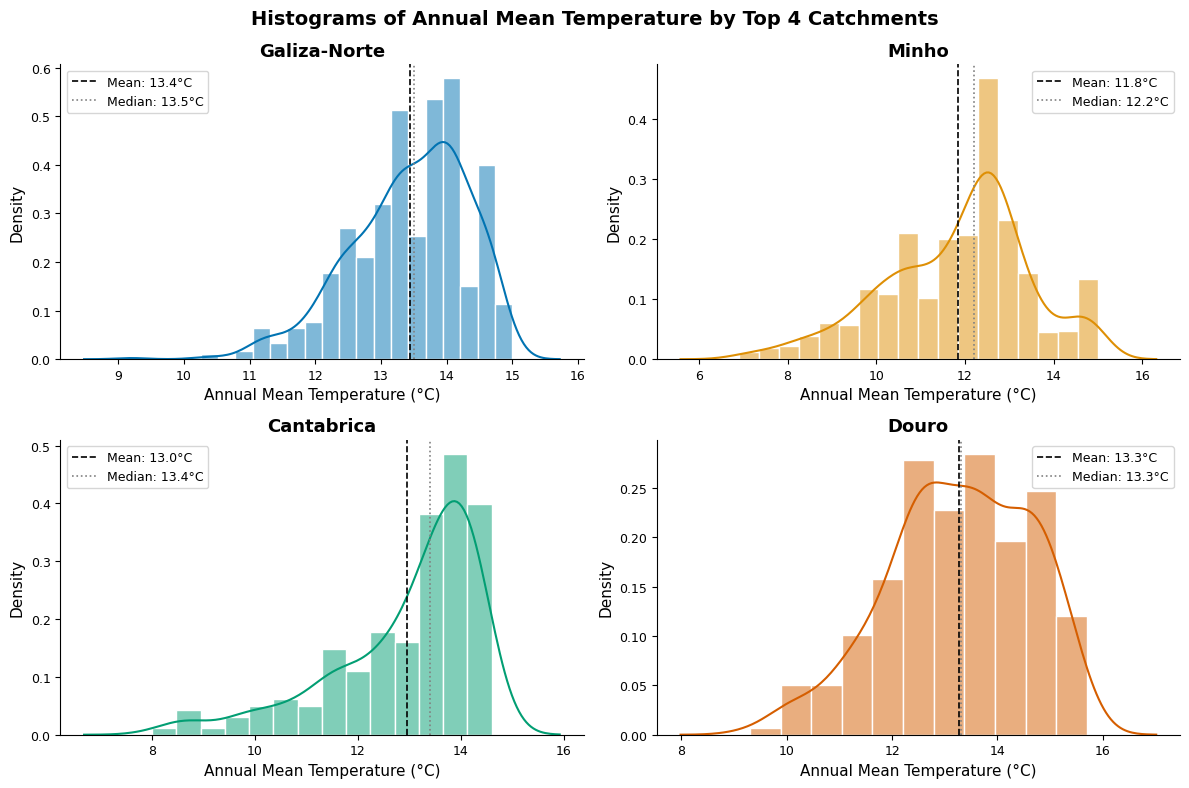

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histograms of Annual Mean Temperature by Top 4 Catchments',fontsize=TITLE_FS+1, fontweight='bold')

for ax, catchment in zip(axes.flatten(), top4):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.histplot(data, kde=True, stat='density', color=palette[catchment],
                 alpha=0.5, edgecolor='white', kde_kws=dict(cut=3), ax=ax)
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {data.mean():.1f}°C')
    ax.axvline(data.median(), color='grey',  linestyle=':',  linewidth=1.2,
               label=f'Median: {data.median():.1f}°C')
    ax.set_title(catchment, fontsize=TITLE_FS, fontweight='bold')
    ax.set_xlabel(VAR_LABEL, fontsize=LABEL_FS)
    ax.set_ylabel('Density', fontsize=LABEL_FS)
    ax.legend(fontsize=TICK_FS)
    clean_ax(ax)

plt.tight_layout()
plt.show()


## 5. Boxplots

Boxplots summarise the distribution using five key statistics: minimum, Q1, median, Q3, and maximum, with outliers plotted individually. They are compact and ideal for comparing distributions across groups.

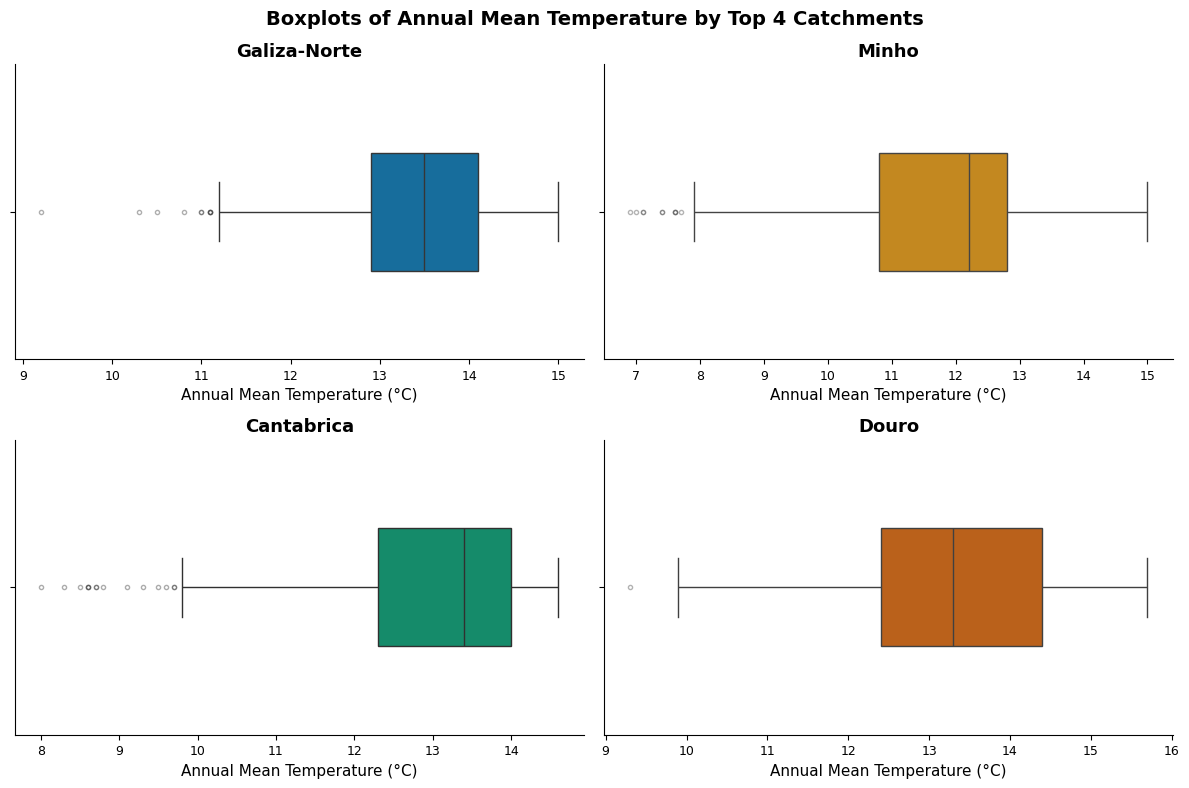

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
fig.suptitle('Boxplots of Annual Mean Temperature by Top 4 Catchments',fontsize=TITLE_FS+1, fontweight='bold')

for ax, catchment in zip(axes.flatten(), top4):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.boxplot(x=data, color=palette[catchment], width=0.4,
                flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)
    ax.set_title(catchment, fontsize=TITLE_FS, fontweight='bold')
    ax.set_xlabel(VAR_LABEL, fontsize=LABEL_FS)
    clean_ax(ax)

plt.tight_layout()
plt.show()


## 6. Raincloud Plots

Raincloud plots combine a half-violin (distribution shape), a boxplot (summary statistics), and a strip plot (individual points) into a single figure — providing the most complete univariate view.

/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:779: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:779: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` va

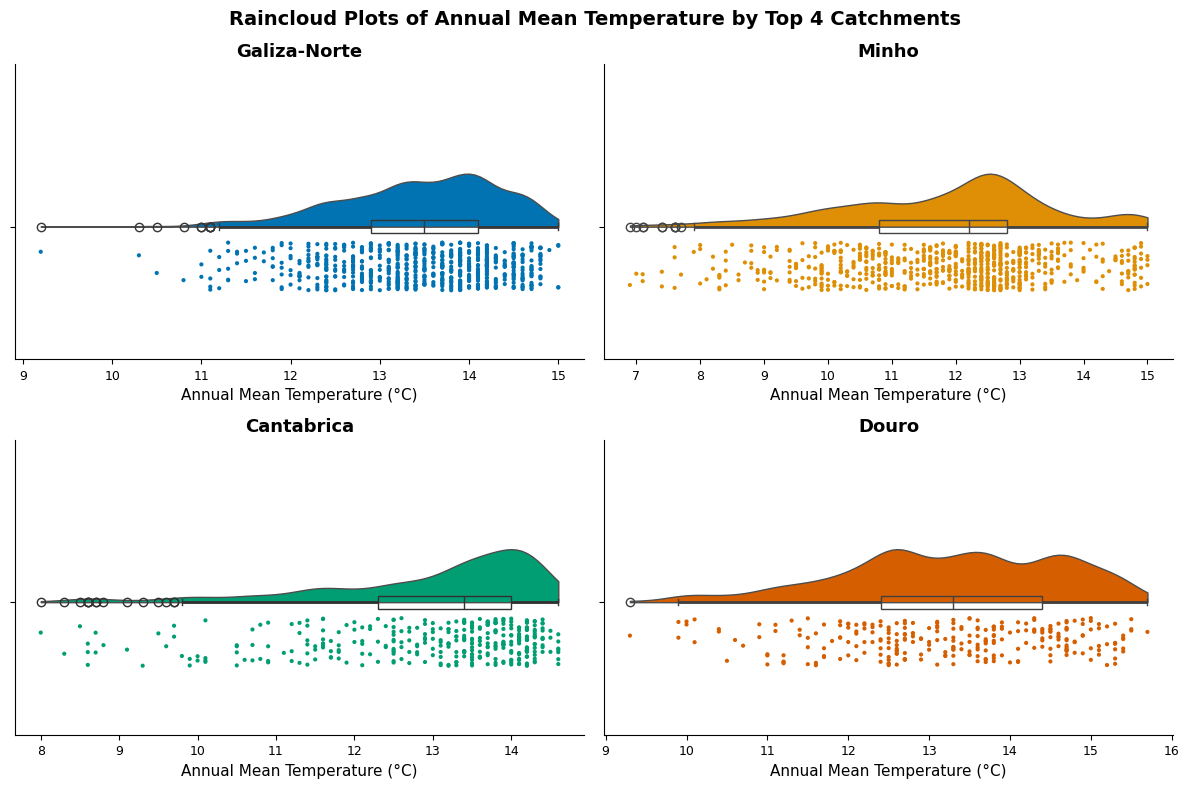

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
fig.suptitle('Raincloud Plots of Annual Mean Temperature by Top 4 Catchments',fontsize=TITLE_FS+1, fontweight='bold')

for ax, catchment in zip(axes.flatten(), top4):
    data = df_top4[df_top4['Catchment_name'] == catchment]
    pt.RainCloud(y='temp_ann', data=data,
                 palette=[palette[catchment]],
                 bw=0.2, width_viol=0.4, width_box=0.05,
                 orient='h', move=0.15, offset=0, jitter=0.09, ax=ax)
    ax.set_title(catchment, fontsize=TITLE_FS, fontweight='bold')
    ax.set_xlabel(VAR_LABEL, fontsize=LABEL_FS)
    ax.set_ylabel("")
    clean_ax(ax)

plt.tight_layout()
plt.show()


## 7. Pros and Cons of Each Plot Type

| Plot Type | Pros | Cons |
|-----------|------|------|
| **Strip Plot** | Shows every individual data point; reveals clusters, gaps and outliers directly; no information is lost | Can become overplotted with large datasets; hard to read the overall distribution shape |
| **Histogram** | Clearly shows the shape of the distribution (skewness, modality); intuitive for most audiences; KDE overlay adds smoothed estimate | Sensitive to bin width choice; does not show individual data points; can mask multimodality with wide bins |
| **Boxplot** | Very compact; easy comparison of median, spread and outliers; robust to large datasets | Hides the distribution shape entirely (e.g. bimodal distributions look the same as unimodal); no individual points visible |
| **Raincloud Plot** | Combines all three above — distribution shape, summary stats and raw data in one view; best practice for complete univariate description | More complex to build and interpret; requires additional library (ptitprince); can look busy for non-specialist audiences |


## 8. Bootstrap Sampling — Convergence of the Sample Mean

To understand how many observations are needed for a stable estimate of the population mean of , we take 1000 random samples **with replacement** at increasing sample sizes and plot the mean and 95% CI of those sample means.

In [13]:
sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000]
n_iter = 1000
pop_mean = df2['temp_ann'].mean()

results = []
for n in sample_sizes:
    means = [df2['temp_ann'].sample(n, replace=True).mean() for _ in range(n_iter)]
    results.append({
        'n': n,
        'mean_of_means': np.mean(means),
        'std': np.std(means),
        'ci_lo': np.percentile(means, 2.5),
        'ci_hi': np.percentile(means, 97.5)
    })

res = pd.DataFrame(results)
print(res.round(4).to_string(index=False))


   n  mean_of_means    std   ci_lo   ci_hi
  10        13.4377 0.6287 12.1988 14.6705
  50        13.4392 0.2686 12.8980 13.9522
 100        13.4287 0.1861 13.0670 13.7841
 150        13.4341 0.1513 13.1293 13.7208
 200        13.4303 0.1379 13.1615 13.6946
 250        13.4385 0.1150 13.2136 13.6621
 300        13.4286 0.1093 13.2167 13.6423
 500        13.4289 0.0864 13.2554 13.5890
1000        13.4307 0.0565 13.3183 13.5409


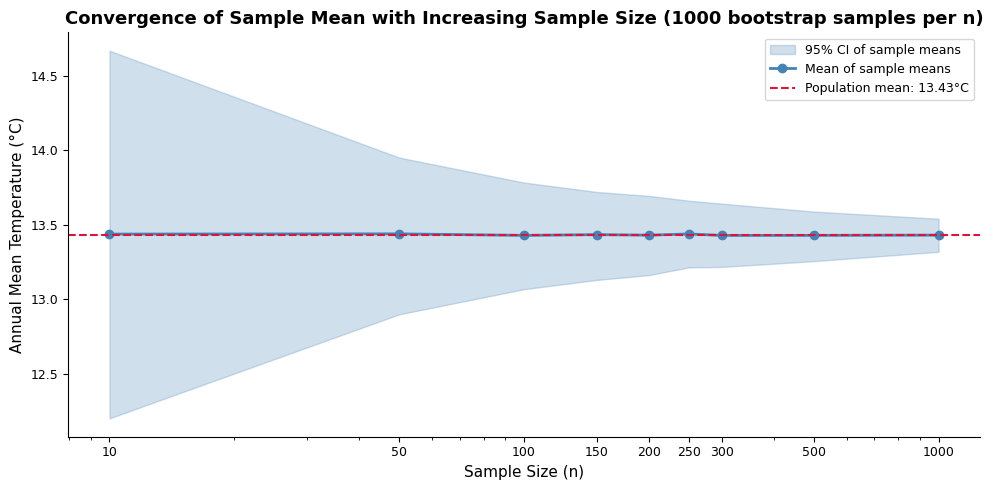

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(res['n'], res['ci_lo'], res['ci_hi'],
                alpha=0.25, color='steelblue', label='95% CI of sample means')
ax.plot(res['n'], res['mean_of_means'],
        color='steelblue', marker='o', linewidth=2, label='Mean of sample means')
ax.axhline(pop_mean, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Population mean: {pop_mean:.2f}°C')

ax.set_xlabel('Sample Size (n)', fontsize=LABEL_FS)
ax.set_ylabel('Annual Mean Temperature (°C)', fontsize=LABEL_FS)
ax.set_title('Convergence of Sample Mean with Increasing Sample Size (1000 bootstrap samples per n)', fontsize=TITLE_FS, fontweight='bold')
ax.legend(fontsize=TICK_FS)
ax.set_xscale('log')
ax.set_xticks(sample_sizes)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
clean_ax(ax)

plt.tight_layout()
plt.show()


### Interpretation

The 95% confidence interval narrows substantially as sample size increases. By **n ≈ 200–300**, the CI becomes very tight and the sample mean consistently converges to the population mean (~13.4°C). Beyond n = 300, the additional gain in precision is marginal — suggesting that around **200–300 observations** provide a reliable estimate of the population mean for  in this dataset.